In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
def load_data(dataset_path, img_size=(128, 128)):
    X, y = [], []
    class_names = sorted(os.listdir(dataset_path))
    class_indices = {name: idx for idx, name in enumerate(class_names)}

    for label in class_names:
        class_path = os.path.join(dataset_path, label)
        for file in os.listdir(class_path):
            if file.lower().endswith(('.jpg', '.png', '.bmp')):
                path = os.path.join(class_path, file)
                img = cv2.imread(path)
                img = cv2.resize(img, img_size)
                X.append(img)
                y.append(class_indices[label])

    X = np.array(X, dtype='float32') / 255.0
    y = to_categorical(y)
    return X, y, class_names

In [4]:
dataset_path = "/content/drive/MyDrive/Flying object detection system/1/UAV_Dataset"
X, y, class_names = load_data(dataset_path)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
#Побудова моделі CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.3711 - loss: 1.5753 - val_accuracy: 0.6322 - val_loss: 0.8813
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6711 - loss: 0.8095 - val_accuracy: 0.7294 - val_loss: 0.6635
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7864 - loss: 0.5736 - val_accuracy: 0.7835 - val_loss: 0.5589
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8540 - loss: 0.4075 - val_accuracy: 0.8007 - val_loss: 0.5118
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9037 - loss: 0.2921 - val_accuracy: 0.8020 - val_loss: 0.5407
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9078 - loss: 0.2431 - val_accuracy: 0.7872 - val_loss: 0.6804
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9406 - loss: 0.1880 - val_accuracy: 0.8118 - val_loss: 0.5595
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9532 - loss: 0.1295 - val_acc

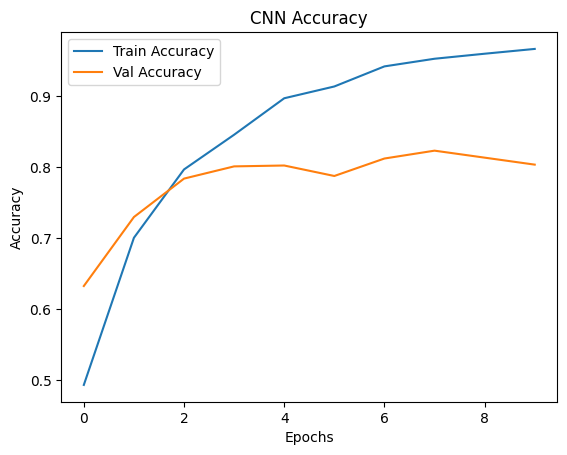

In [7]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()